# OpenDataBattle2026 Phase2 データ加工【空気】- NO2, PM2.5

#### [1]読み込み
#### [2]前処理
#### [3]集計

##### 「年平均NO2濃度」より、以下2つの指標を採用。
- 代表値：中央値（データにばらつきあるため）
- 特徴　：最大値（外れ値がある都市には、濃度が高くなる要因をもつ地域があるとわかる）

## 【読み込み】

### ライブラリ読み込み

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### データ読み込み

In [2]:
# 県庁所在地一覧
df_prefectural_capitals = pd.read_csv("../data/raw_00_reference_県庁所在地一覧_20260803.csv", encoding='shift_jis')

# NO2濃度データ
df_NO2 = pd.read_table("../data/raw_02_atmospheric_全国NO2濃度_20260828.txt", encoding='shift_jis', sep=',')
# PM2.5データ
df_pm25 = pd.read_table("../data/raw_02_atmospheric_全国PM2.5濃度_20260828.txt", encoding='shift_jis', sep=',')

## 【データ確認】

### 県庁所在地一覧データ

In [3]:
# 末尾３件確認
df_prefectural_capitals.tail(3)

,コード,都道府県,県庁所在地,ローマ字
44,45,宮崎県,宮崎市,miyazaki
45,46,鹿児島県,鹿児島市,kagoshima
46,47,沖縄県,那覇市,naha


In [4]:
# 概要
df_prefectural_capitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   コード     47 non-null     int64
 1   都道府県    47 non-null     str  
 2   県庁所在地   47 non-null     str  
 3   ローマ字    47 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.6 KB


#### NO2濃度データ

In [5]:
# 頭2件確認
df_NO2.head(2)

,測定年度,項目種類コード,項目コード_数字,項目コード_英数字,測定方法コード,都道府県コード,都道府県名,都道府県_ローマ字,市区町村コード,市区町村名,...,日平均値が0.04ppm以上0.06ppm以下の日数(日)_６月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_７月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_８月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_９月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_10月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_11月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_12月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_１月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_２月,日平均値が0.04ppm以上0.06ppm以下の日数(日)_３月
0,2023,1,3,NO2,2,1,北海道,Hokkai-do,1101,札幌市中央区,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,0.0
1,2023,1,3,NO2,2,1,北海道,Hokkai-do,1101,札幌市中央区,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [6]:
# 概要
df_NO2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1550 entries, 0 to 1549
Columns: 143 entries, 測定年度 to 日平均値が0.04ppm以上0.06ppm以下の日数(日)_３月
dtypes: float64(91), int64(44), str(8)
memory usage: 1.7 MB


### PM2.5データ

In [7]:
# 頭2件確認
df_pm25.head(2)

,測定年度,項目種類コード,項目コード_数字,項目コード_英数字,測定方法コード,都道府県コード,都道府県名,都道府県名_ローマ字,市区町村コード,市区町村名,...,月間集計項目9_６月,月間集計項目9_７月,月間集計項目9_８月,月間集計項目9_９月,月間集計項目9_10月,月間集計項目9_11月,月間集計項目9_12月,月間集計項目9_１月,月間集計項目9_２月,月間集計項目9_３月
0,2023,1,12,PM25,11,1,北海道,Hokkai-do,1101,札幌市中央区,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1,12,PM25,11,1,北海道,Hokkai-do,1101,札幌市中央区,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# 概要
df_pm25.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Columns: 143 entries, 測定年度 to 月間集計項目9_３月
dtypes: float64(107), int64(28), str(8)
memory usage: 1.2 MB


## 【前処理】

### 県庁所在地データ

In [9]:
### 東京都の県庁所在地が「東京都」になっているので「東京」に変更
df_prefectural_capitals["県庁所在地"] = df_prefectural_capitals["県庁所在地"].replace(
    "東京都", "東京"
)
df_prefectural_capitals["県庁所在地"].unique()

<StringArray>
[  '札幌市',   '青森市',   '盛岡市',   '仙台市',   '秋田市',   '山形市',   '福島市',   '水戸市',
  '宇都宮市',   '前橋市', 'さいたま市',   '千葉市',    '東京',   '横浜市',   '新潟市',   '富山市',
   '金沢市',   '福井市',   '甲府市',   '長野市',   '岐阜市',   '静岡市',  '名古屋市',    '津市',
   '大津市',   '京都市',   '大阪市',   '神戸市',   '奈良市',  '和歌山市',   '鳥取市',   '松江市',
   '岡山市',   '広島市',   '山口市',   '徳島市',   '高松市',   '松山市',   '高知市',   '福岡市',
   '佐賀市',   '長崎市',   '熊本市',   '大分市',   '宮崎市',  '鹿児島市',   '那覇市']
Length: 47, dtype: str

### NO2濃度データ

In [10]:
# 使用するカラムをリスト化して抽出
list_no2 = [
    "測定年度",
    "都道府県名",
    "市区町村コード",
    "市区町村名",
    "測定局名",
    "測定局区分コード",
    "測定局種別コード",
    "用途地域名",
    "有効測定日数(日)",
    "測定時間(時間)",
    "年平均値(ppm)"
]
df_NO2 = df_NO2[list_no2]
df_NO2.head(2)

,測定年度,都道府県名,市区町村コード,市区町村名,測定局名,測定局区分コード,測定局種別コード,用途地域名,有効測定日数(日),測定時間(時間),年平均値(ppm)
0,2023,北海道,1101,札幌市中央区,北１条,2,0,商,365,8724,0.015
1,2023,北海道,1101,札幌市中央区,南１４条,2,0,商,365,8737,0.012


In [12]:
# 市町村名から県庁所在地が含まれているデータを抽出し、県庁所在地カラムも作成する

### 県庁所在地名をリスト化
capital_names = df_prefectural_capitals["県庁所在地"].tolist()

### 市区町村名から県庁所在地名を取得する関数
def get_capital(city_name):
    
    # 一応市区町村名を文字列に変換
    city_name = str(city_name)

    # 返り値
    ### - next()中身を順番に取り出す、今回は1回しか使っていないので実質毎回一つ目だけ取り出している
    return next(
        ### 県庁所在地リストを回して、引数の市町村名に含まれているものだけ保持、含まれていなかったらNoneとする
        (capital for capital in capital_names if capital in city_name),
        None
    )


### 処理対象のデータフレームのコピーを作成
df_NO2_capitals = df_NO2.copy()

### 上記で作成した関数を適用して、各市町村名から県庁所在地というカラムを作成
# - apply() 関数を全てに適用
df_NO2_capitals["県庁所在地"] = df_NO2_capitals["市区町村名"].apply(
    get_capital
)

#-- 例外処理 --#
### 市区町村名に「大津市」が含まれるデータの県庁所在地が「津市」に判定されるため、「大津市」に変更
df_NO2_capitals.loc[
    df_NO2_capitals["市区町村名"].str.contains("大津市", na=False),
    "県庁所在地"
] = "大津市"

### 県庁所在地名がNaNではないデータのみ抽出
df_NO2_capitals = df_NO2_capitals[
    df_NO2_capitals["県庁所在地"].notna()
].copy()

df_NO2_capitals.head(2)

,測定年度,都道府県名,市区町村コード,市区町村名,測定局名,測定局区分コード,測定局種別コード,用途地域名,有効測定日数(日),測定時間(時間),年平均値(ppm),県庁所在地
0,2023,北海道,1101,札幌市中央区,北１条,2,0,商,365,8724,0.015,札幌市
1,2023,北海道,1101,札幌市中央区,南１４条,2,0,商,365,8737,0.012,札幌市


In [13]:
# 市町村名から県庁所在地が含まれているデータを抽出し、県庁所在地カラムも作成する
#### ※東京都だけ別処理 ####
# 都道府県名が東京都、かつ、市区町村名が"区"で終わるデータのみ抽出
df_NO2_tokyo = df_NO2[
    (df_NO2["都道府県名"] == "東京都") &
    (df_NO2["市区町村名"].str.endswith("区"))
].copy()
# 県庁所在地を東京とする
df_NO2_tokyo["県庁所在地"] = "東京"
df_NO2_tokyo.head(2)

,測定年度,都道府県名,市区町村コード,市区町村名,測定局名,測定局区分コード,測定局種別コード,用途地域名,有効測定日数(日),測定時間(時間),年平均値(ppm),県庁所在地
444,2023,東京都,13101,千代田区,千代田区神田司町,1,0,商,359,8513,0.015,東京
445,2023,東京都,13101,千代田区,日比谷交差点,2,0,商,363,8584,0.018,東京


In [14]:
# 東京のデータをデータフレームに結合
df_NO2_capitals = pd.concat(
    [df_NO2_capitals, df_NO2_tokyo],
    ignore_index=True
)

### PM2.5濃度データ

In [15]:
# 使用するカラムをリスト化して抽出
list_pm25 = [
    "測定年度",
    "都道府県名",
    "市区町村名",
    "測定局コード",
    "測定局名",
    "測定局種別コード",
    "用途地域名",
    "有効測定日数(日)",
    "年平均値(μg/m3)",
    "日平均値の年間98%値(μg/m3)",
    "日平均値が35μg/m3を超えた日数(日)",
]
df_pm25 = df_pm25[list_pm25]
df_pm25.head(2)

,測定年度,都道府県名,市区町村名,測定局コード,測定局名,測定局種別コード,用途地域名,有効測定日数(日),年平均値(μg/m3),日平均値の年間98%値(μg/m3),日平均値が35μg/m3を超えた日数(日)
0,2023,北海道,札幌市中央区,1101520,北１条,0,商,354,8.5,19.8,1
1,2023,北海道,札幌市中央区,1101540,南１４条,0,商,356,6.1,15.9,0


In [16]:
# 市町村名から県庁所在地が含まれているデータを抽出し、県庁所在地カラムも作成する

### 処理対象のデータフレームのコピーを作成
df_pm25_capitals = df_pm25.copy()

### 上記で作成した関数を適用して、各市町村名から県庁所在地というカラムを作成
# - apply() 関数を全てに適用
df_pm25_capitals["県庁所在地"] = df_pm25_capitals["市区町村名"].apply(
    get_capital
)

#-- 例外処理 --#
### 市区町村名に「大津市」が含まれるデータの県庁所在地が「津市」に判定されるため、「大津市」に変更
df_pm25_capitals.loc[
    df_pm25_capitals["市区町村名"].str.contains("大津市", na=False),
    "県庁所在地"
] = "大津市"

### 県庁所在地名がNaNではないデータのみ抽出
df_pm25_capitals = df_pm25_capitals[
    df_pm25_capitals["県庁所在地"].notna()
].copy()

df_pm25_capitals.head(2)

,測定年度,都道府県名,市区町村名,測定局コード,測定局名,測定局種別コード,用途地域名,有効測定日数(日),年平均値(μg/m3),日平均値の年間98%値(μg/m3),日平均値が35μg/m3を超えた日数(日),県庁所在地
0,2023,北海道,札幌市中央区,1101520,北１条,0,商,354,8.5,19.8,1,札幌市
1,2023,北海道,札幌市中央区,1101540,南１４条,0,商,356,6.1,15.9,0,札幌市


In [17]:
# 市町村名から県庁所在地が含まれているデータを抽出し、県庁所在地カラムも作成する
#### ※東京都だけ別処理 ####
# 都道府県名が東京都、かつ、市区町村名が"区"で終わるデータのみ抽出
df_pm25_tokyo = df_pm25[
    (df_pm25["都道府県名"] == "東京都") &
    (df_pm25["市区町村名"].str.endswith("区"))
].copy()
# 県庁所在地を東京とする
df_pm25_tokyo["県庁所在地"] = "東京"
df_pm25_tokyo.head(2)

,測定年度,都道府県名,市区町村名,測定局コード,測定局名,測定局種別コード,用途地域名,有効測定日数(日),年平均値(μg/m3),日平均値の年間98%値(μg/m3),日平均値が35μg/m3を超えた日数(日),県庁所在地
281,2023,東京都,千代田区,13101010,千代田区神田司町,0,商,356,12.0,25.5,0,東京
282,2023,東京都,千代田区,13101510,日比谷交差点,0,商,359,10.7,23.6,0,東京


In [18]:
# 東京のデータをデータフレームに結合
df_pm25_capitals = pd.concat(
    [df_pm25_capitals, df_pm25_tokyo],
    ignore_index=True
)

## 【可視化】

In [19]:
# 県庁所在地ごとのデータ数をカウント
df_pm25_capitals["県庁所在地"].value_counts()

県庁所在地
東京       58
横浜市      20
津市       19
名古屋市     18
神戸市      17
大阪市      16
仙台市      14
札幌市      13
広島市      12
新潟市      11
京都市      11
千葉市       9
静岡市       9
福岡市       9
熊本市       8
さいたま市     7
松山市       7
長野市       7
岡山市       7
大分市       7
金沢市       6
和歌山市      6
高松市       5
宮崎市       5
富山市       4
大津市       4
長崎市       4
鹿児島市      4
秋田市       3
山形市       3
甲府市       3
岐阜市       3
盛岡市       2
福島市       2
宇都宮市      2
福井市       2
佐賀市       2
青森市       1
水戸市       1
前橋市       1
奈良市       1
鳥取市       1
松江市       1
山口市       1
徳島市       1
高知市       1
那覇市       1
Name: count, dtype: int64

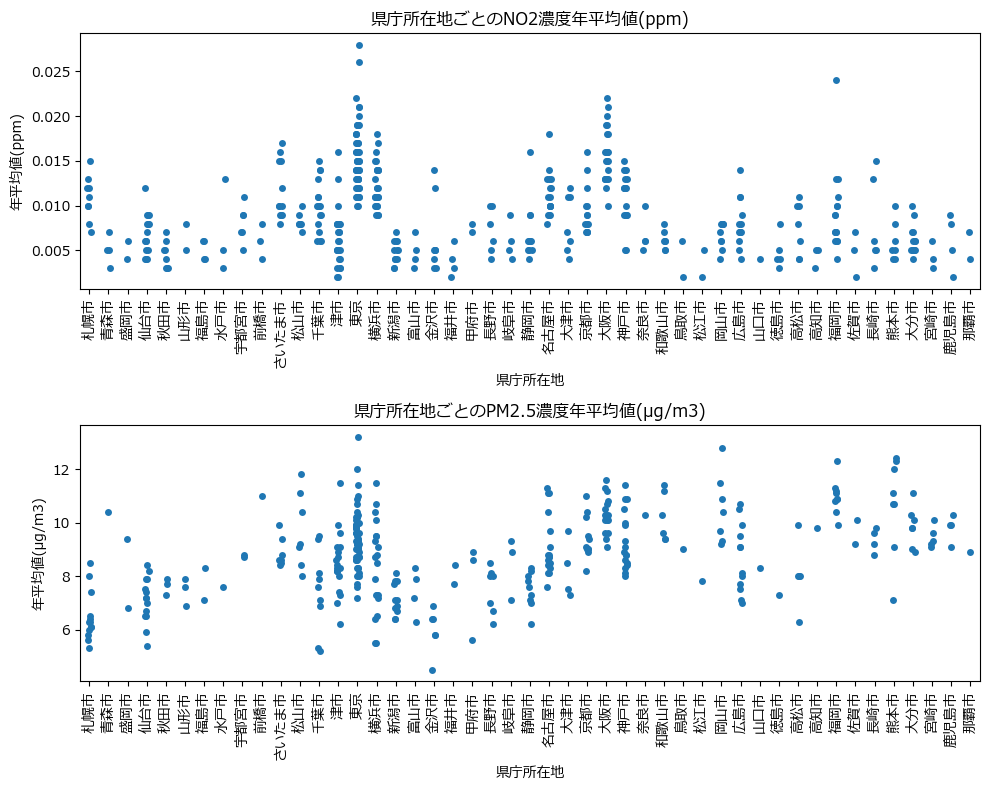

In [20]:
# 簡単に可視化して47都市の分布を比較してみる
### ジッタープロット

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.stripplot(
    ax=axes[0],
    data=df_NO2_capitals,
    x="県庁所在地",
    y="年平均値(ppm)",
    jitter=True
)

sns.stripplot(
    ax=axes[1],
    data=df_pm25_capitals,
    x="県庁所在地",
    y="年平均値(μg/m3)",
    jitter=True
)

axes[0].set_title("県庁所在地ごとのNO2濃度年平均値(ppm)")
axes[1].set_title("県庁所在地ごとのPM2.5濃度年平均値(μg/m3)")

#　ループで横軸の文字の回転を設定
for ax in axes:
    ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

グラフから以下の集計科目を採用
#### NO2濃度
- 代表値：中央値（データにばらつきあるため）
- 特徴　：最大値（外れ値がある都市には、濃度が高くなる要因をもつ地域があるとわかる）
###### なお、PM2.5については、東北よりも九州の濃度が高いところから、
- 都市要因ではなく、地理的要因が関係している可能性がある
###### よって、PM2.5濃度の中央値と最大値は集計しつつも採用はしない方針とする。

### 東京について測定値の用途によってデータがどう分布しているのか確認

In [21]:
# NO2とPM2.5の年平均値を測定局単位で結合
df_tokyo_air = df_NO2_tokyo[
    ["測定局名", "用途地域名", "年平均値(ppm)"]
].merge(
    df_pm25_tokyo[
        ["測定局名", "年平均値(μg/m3)"]
    ],
    on="測定局名",
    how="inner"
)
print(df_tokyo_air.shape)
df_tokyo_air.head(2)

(54, 4)


,測定局名,用途地域名,年平均値(ppm),年平均値(μg/m3)
0,千代田区神田司町,商,0.015,12.0
1,日比谷交差点,商,0.018,10.7


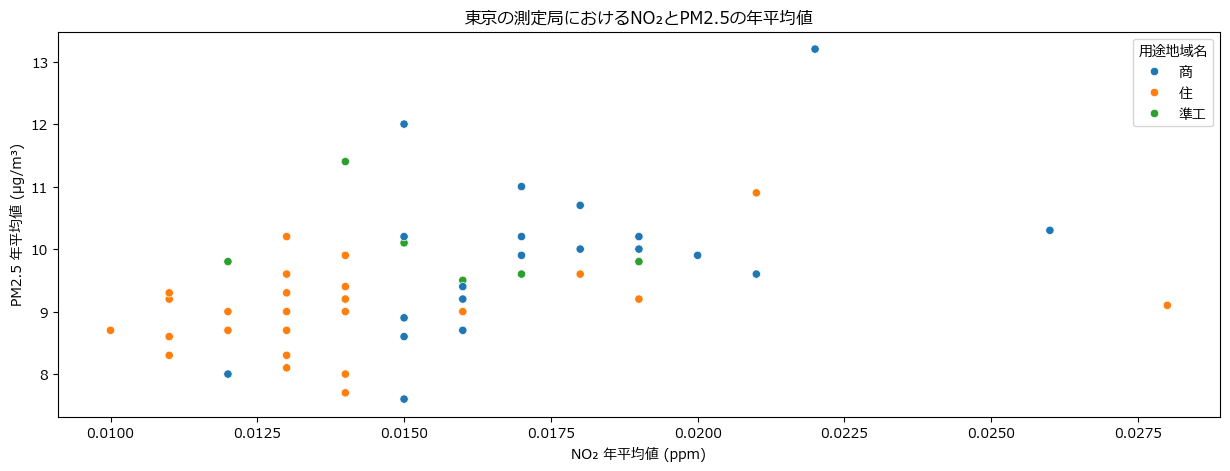

In [22]:
plt.figure(figsize=(15, 5))

sns.scatterplot(
    data=df_tokyo_air,
    x="年平均値(ppm)",
    y="年平均値(μg/m3)",
    hue="用途地域名"
)

plt.xlabel("NO₂ 年平均値 (ppm)")
plt.ylabel("PM2.5 年平均値 (μg/m³)")
plt.title("東京の測定局におけるNO₂とPM2.5の年平均値")
plt.show()

##### 東京の散布図より以下の傾向が読み取れる。
- "住"、"準工"、"商"の順に各濃度は高くなる
##### このデータでは県庁所在地ごとの測定数の差が大きい。（東京は約50地点、大都市で約20地点、少ない都市では1地点）
##### よって、
##### 用途地域名を利用した集計の補正は行わない方向とする。

## 【Tableau可視化用データ作成】

In [33]:
# Tableau用にNO2濃度とPM2.5濃度のデータを結合したデータフレーム作成（測定地点でinner）
# NO2から必要なカラムを抽出
df_air_NO2 = df_NO2_capitals[
    [
        "測定年度",
        "都道府県名",
        "市区町村名",
        "測定局名",
        "用途地域名",
        "県庁所在地",
        "年平均値(ppm)"
    ]
].copy()

# PM2.5から必要なカラムを抽出
df_air_pm25 = df_pm25_capitals[
    [
        "測定年度",
        "都道府県名",
        "市区町村名",
        "測定局名",
        "用途地域名",
        "県庁所在地",
        "年平均値(μg/m3)"
    ]
].copy()

# 測定局コードをキーにNO2とPM2.5を結合
df_air = df_air_NO2.merge(
    df_air_pm25,
    on=[
        "測定年度",
        "都道府県名",
        "市区町村名",
        "測定局名",
        "用途地域名",
        "県庁所在地"
    ],
    how="inner"
)

# 平均値カラムをそれぞれ変更しておく
df_air = df_air.rename(
    columns={
        "年平均値(ppm)": "NO2濃度_年平均値(ppm)",
        "年平均値(μg/m3)": "PM2.5濃度 _年平均値(μg/m3)"
    }
)

df_air.head(2)

,測定年度,都道府県名,市区町村名,測定局名,用途地域名,県庁所在地,NO2濃度_年平均値(ppm),PM2.5濃度 _年平均値(μg/m3)
0,2023,北海道,札幌市中央区,北１条,商,札幌市,0.015,8.5
1,2023,北海道,札幌市中央区,南１４条,商,札幌市,0.012,6.1


In [34]:
print("データサイズ", df_air.shape)
print("県庁所在地のユニーク数", df_air["県庁所在地"].nunique())

データサイズ (325, 8)
県庁所在地のユニーク数 47


## 【集計】

In [46]:
# 集計
df_air_quality_summary = (
    df_air
    .groupby("県庁所在地")
    .agg(
        観測数=("県庁所在地", "size"),
        NO2_median=("NO2濃度_年平均値(ppm)", "median"),
        NO2_max=("NO2濃度_年平均値(ppm)", "max"),
        pm25_median=("PM2.5濃度 _年平均値(μg/m3)", "median"),
        pm25_max=("PM2.5濃度 _年平均値(μg/m3)", "max"),
    )
    .reset_index()
)
df_air_quality_summary.head(2)

,県庁所在地,観測数,NO2_median,NO2_max,pm25_median,pm25_max
0,さいたま市,7,0.010,0.016,8.6,9.9
1,京都市,11,0.009,0.016,9.1,11.0


In [47]:
# 集計結果を県庁所在地データにマージ
df_analysis_air_quality = df_prefectural_capitals.merge(
    df_air_quality_summary,
    on="県庁所在地",
    how="left"
)
df_analysis_air_quality.head(3)

,コード,都道府県,県庁所在地,ローマ字,観測数,NO2_median,NO2_max,pm25_median,pm25_max
0,1,北海道,札幌市,sapporo,9,0.011,0.015,6.4,8.5
1,2,青森県,青森市,aomori,1,0.005,0.005,10.4,10.4
2,3,岩手県,盛岡市,morioka,2,0.005,0.006,8.1,9.4


### 【集計した値を可視化してみる】

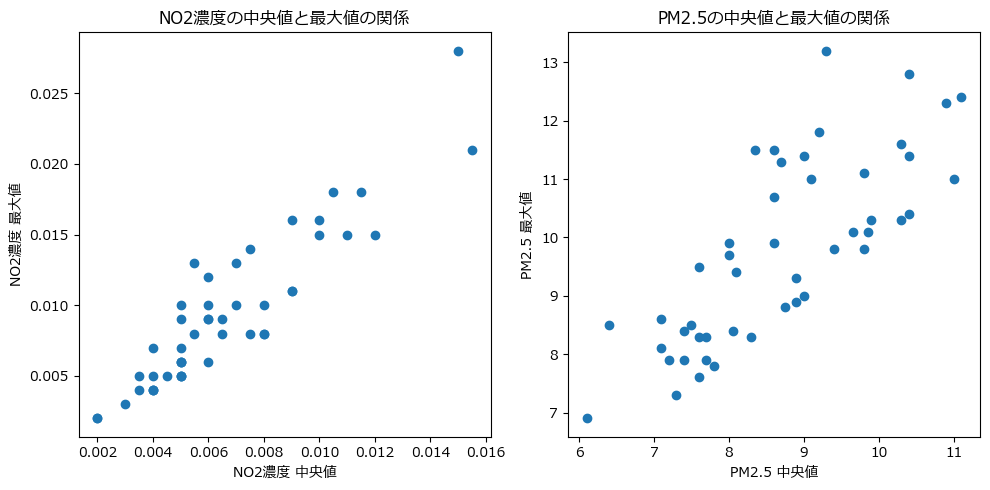

In [48]:
# 硬度・pHそれぞれの指標ごとに散布図
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ① 硬度中央値 × Max
axes[0].scatter(
    df_air_quality_summary["NO2_median"],
    df_air_quality_summary["NO2_max"]
)

axes[0].set_xlabel("NO2濃度 中央値")
axes[0].set_ylabel("NO2濃度 最大値")
axes[0].set_title("NO2濃度の中央値と最大値の関係")

# ② pH平均 × IQR
axes[1].scatter(
    df_air_quality_summary["pm25_median"],
    df_air_quality_summary["pm25_max"]
)

axes[1].set_xlabel("PM2.5 中央値")
axes[1].set_ylabel("PM2.5 最大値")
axes[1].set_title("PM2.5の中央値と最大値の関係")

plt.tight_layout()
plt.show()

In [50]:
# csv出力
### 加工済みデータ
df_air.to_csv("../data/data_air_quality.csv")
### 集計結果
df_air_quality_summary.to_csv("../data/df_analysis_air_quality.csv")